# Расчёт рекомендаций (часть 1, этапы 1–3)

Ноутбук считает рекомендации для интернет-магазина по данным Retailrocket:
разбивает события по времени, строит базовую модель (топ популярных),
обучает ALS, подбирает его гиперпараметры Optuna и рассчитывает похожие
товары. Все эксперименты логируются в MLflow, артефакты выгружаются в S3.

Вся логика вынесена в пакет `recsys` (`recsys/data.py`, `recsys/features.py`,
`recsys/models.py`, `recsys/metrics.py`) — те же функции используют стадии DVC
и шаги DAG, поэтому в ноутбуке остаются только вызовы и выводы.

## Инициализация

Импорты, параметры пайплайна из `params.yaml` и подключение к MLflow.
Значения параметров не задаются в ноутбуке руками: даты сплитов, веса событий
и гиперпараметры лежат в `params.yaml` в корне репозитория.

In [1]:
import json
import os
import sys
import time
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import yaml
from mlflow.models import infer_signature
from sklearn.metrics import log_loss, roc_auc_score

# ноутбук лежит в notebooks/, пакет recsys — в корне репозитория
sys.path.insert(0, os.path.abspath(".."))

from recsys.config import (
    ALS_MODEL_PATH,
    ID_MAPS_PATH,
    RECS_DEFAULT_PATH,
    RECS_PERSONAL_PATH,
    S3_BUCKET,
    S3_PREFIX,
    SEED,
    SIMILAR_PATH,
)
from recsys.data import load_events, load_items, split_events
from recsys.features import (
    CAT_FEATURES,
    RANKER_FEATURES,
    add_target,
    build_candidates,
    build_matrix,
    decode,
    encode,
    holdout_users,
    item_features,
    positives,
    ranker_features,
    sample_negatives,
    user_category_affinity,
    user_features,
    user_history_purchases,
    weight_events,
)
from recsys.metrics import evaluate
from recsys.models import (
    als_recommend,
    fit_als,
    fit_ranker,
    rank_candidates,
    save_als,
    save_ranker,
    similar_items,
    top_by_score,
    top_popular,
)
from recsys.s3_io import (
    list_objects,
    upload_file,
    upload_file_if_changed,
    write_parquet,
)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# в выводе не нужны предупреждения библиотек и ссылки на запуски, которые
# MLflow 3.x печатает сам: идентификаторы запусков печатаются явно ниже
warnings.filterwarnings("ignore")
os.environ["MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT"] = "true"
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Параметры проекта ---
with open("../params.yaml") as fd:
    params = yaml.safe_load(fd)

SPLIT_DATES   = {k: v for k, v in params.items() if k.startswith("split_")}
EVENT_WEIGHTS = params["event_weights"]        # view 1, addtocart 5, transaction 10
ALS_FACTORS   = params["als"]["factors"]
ALS_REG       = params["als"]["regularization"]
ALS_ITERS     = params["als"]["iterations"]
N_TRIALS      = params["optuna"]["n_trials"]   # число попыток подбора Optuna
TOP_K         = params["top_k"]                # глубина выдачи, на ней считаем метрики
N_CANDIDATES  = params["n_candidates"]         # длина списка популярного
N_SIMILAR     = params["n_similar"]            # сколько похожих товаров на товар
CANDIDATES    = params["candidates"]           # размеры пула кандидатов
CB_PARAMS     = params["catboost"]             # гиперпараметры ранжировщика
N_NEGATIVES   = CANDIDATES["negatives_per_user"]
HOLDOUT_SHARE = CANDIDATES["holdout_share"]
MIN_USER_EVENTS = params["min_user_events"]    # кому считаем персональные рекомендации
RECS_TOP_N    = params["recs_top_n"]           # длина списка рекомендаций для сервиса
MODELS_DIR    = "../models"
DATA_DIR      = "../data"
CV_DIR        = "../cv_results"

# модель ALS, обученная на train, уже лежит в бакете: канал наружу около
# 0,1 МБ/с, и перезаливать те же 689 МБ при каждом прогоне ноутбука незачем
UPLOAD_ALS_MODEL = False

EXPERIMENT_NAME = "final_project_recsys"
REGISTRY_MODEL_NAME = "recsys_ranker_model"
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

print("параметры сплита:", SPLIT_DATES)
print("веса событий:", EVENT_WEIGHTS)
print("эксперимент MLflow:", EXPERIMENT_NAME, "| id:", EXPERIMENT_ID)

/home/user/venvs/mle-pr-final/lib/python3.12/site-packages/pydantic/_internal/_fields.py:149: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


/home/user/venvs/mle-pr-final/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


параметры сплита: {'split_train_fit': '2015-05-03', 'split_valid': '2015-08-04', 'split_labels': '2015-08-19', 'split_test': '2015-09-03', 'split_end': '2015-09-19'}
веса событий: {'view': 1, 'addtocart': 5, 'transaction': 10}
эксперимент MLflow: final_project_recsys | id: 9


## Этап 1. Данные и разбиение по времени

Читаем все события из таблицы `retailrocket_events` в Postgres. Это
единственное обращение к базе — дальше всё считается в памяти.

In [2]:
events = load_events()

print(f"событий: {len(events):,}")
print(f"период: {events['event_ts'].min()} — {events['event_ts'].max()}")
print(f"визитёров: {events['visitorid'].nunique():,}")
print(f"товаров: {events['itemid'].nunique():,}")
print(events["event"].value_counts().to_dict())

событий: 2,756,101
период: 2015-05-03 03:00:04.384000 — 2015-09-18 02:59:47.788000
визитёров: 1,407,580
товаров: 235,061
{'view': 2664312, 'addtocart': 69332, 'transaction': 22457}


Разбиение делаем по времени, а не случайно: рекомендательная система
предсказывает будущее поведение, и случайный сплит дал бы заглядывание вперёд.
Границы окон — в `params.yaml`, верхняя граница везде строгая, поэтому событие
попадает ровно в одно окно.

- `train_fit` — обучение ALS при подборе гиперпараметров;
- `valid` — оценка recall@10 в Optuna, тест при подборе не используется;
- `train` = `train_fit` + `valid` — обучение финальной модели;
- `labels` — источник таргета для ранжировщика (этап 4);
- `test` — единственное окно итоговых метрик.

In [3]:
parts = split_events(events, SPLIT_DATES)

split_info = pd.DataFrame(
    [
        {
            "окно": name,
            "начало": part["event_ts"].min().date(),
            "конец": part["event_ts"].max().date(),
            "событий": len(part),
            "визитёров": part["visitorid"].nunique(),
            "товаров": part["itemid"].nunique(),
        }
        for name, part in parts.items()
    ]
)
display(split_info)

# окна не пересекаются: сумма четырёх непересекающихся окон равна всему объёму
n_windows = sum(len(parts[name]) for name in ["train_fit", "valid", "labels", "test"])
print(f"сумма окон: {n_windows:,} | всего событий: {len(events):,}")

,окно,начало,конец,событий,визитёров,товаров
0,train_fit,2015-05-03,2015-08-03,1950977,990109,201952
1,valid,2015-08-04,2015-08-18,269662,155878,77071
2,labels,2015-08-19,2015-09-02,267469,152373,76354
3,test,2015-09-03,2015-09-18,267993,154021,76136
4,train,2015-05-03,2015-08-18,2220639,1131714,213612


сумма окон: 2,756,101 | всего событий: 2,756,101


Веса событий: `view` — 1, `addtocart` — 5, `transaction` — 10. Сырой вес
пары «визитёр — товар» равен сумме весов её событий, а в матрицу кладём
`log1p` от этой суммы: медиана событий на визитёра равна 1, но максимум
доходит до тысяч, логарифм гасит вклад накрутчиков.

Матрицу строим дважды — на `train_fit` для подбора гиперпараметров и на
`train` для финальной модели, чтобы при подборе модель не видела валидацию.

In [4]:
pairs_fit = weight_events(parts["train_fit"], EVENT_WEIGHTS)
matrix_fit, id_maps_fit = build_matrix(pairs_fit)

pairs_train = weight_events(parts["train"], EVENT_WEIGHTS)
matrix_train, id_maps_train = build_matrix(pairs_train)

print(f"train_fit: матрица {matrix_fit.shape}, ненулевых {matrix_fit.nnz:,}")
print(f"train:     матрица {matrix_train.shape}, ненулевых {matrix_train.nnz:,}")
print(f"плотность train: {matrix_train.nnz / np.prod(matrix_train.shape):.2e}")
display(pairs_train[["weight", "value"]].describe().round(3))

train_fit: матрица (990109, 201952), ненулевых 1,513,542
train:     матрица (1131714, 213612), ненулевых 1,725,395
плотность train: 7.14e-06


,weight,value
count,1725395.000,1725395.000
mean,1.510,0.813
std,2.296,0.350
min,1.000,0.693
25%,1.000,0.693
50%,1.000,0.693
75%,1.000,0.693
max,308.000,5.733


Позитивы для оценки — пары «визитёр — товар», по которым в окне оценки
было добавление в корзину или покупка. Просмотры позитивами не считаются:
целевое действие кейса — `addtocart`.

База усреднения одна и та же для всех моделей: пользователи, у которых есть
хотя бы один позитив в окне оценки **и** хотя бы одно событие в истории, на
которой обучалась модель. Пользователя без истории модель в принципе не может
ранжировать, поэтому включать его в среднее бессмысленно.

In [5]:
pos_valid = positives(parts["valid"])
pos_test = positives(parts["test"])

# в базе усреднения — только пользователи с историей в окне обучения
base_valid = np.intersect1d(
    pos_valid["visitorid"].unique(), parts["train_fit"]["visitorid"].unique()
)
base_test = np.intersect1d(
    pos_test["visitorid"].unique(), parts["train"]["visitorid"].unique()
)

print(f"valid: позитивных пар {len(pos_valid):,}, "
      f"пользователей с позитивом {pos_valid['visitorid'].nunique():,}, "
      f"в базе усреднения {len(base_valid):,}")
print(f"test:  позитивных пар {len(pos_test):,}, "
      f"пользователей с позитивом {pos_test['visitorid'].nunique():,}, "
      f"в базе усреднения {len(base_test):,}")

valid: позитивных пар 6,703, пользователей с позитивом 4,158, в базе усреднения 576
test:  позитивных пар 6,448, пользователей с позитивом 3,973, в базе усреднения 383


Дальше — служебные функции ноутбука: популярность товара для `novelty`,
рекомендации ALS в сырых идентификаторах, оценка модели сразу на двух окнах и
запись метрик в MLflow. Метрики на валидации всегда считает модель, обученная
на `train_fit`, метрики на тесте — модель с теми же параметрами, обученная на
`train`.

In [6]:
def item_popularity(events_part):
    """доля визитёров окна, взаимодействовавших с товаром (для novelty)"""
    return (
        events_part.groupby("itemid")["visitorid"].nunique()
        / events_part["visitorid"].nunique()
    )


def bought_enc(events_part, id_maps):
    """пары (user_enc, item_enc) с покупкой в истории — их не рекомендуем"""
    bought = user_history_purchases(events_part)
    enc = pd.DataFrame({
        "user_enc": encode(id_maps, "user", bought["visitorid"]),
        "item_enc": encode(id_maps, "item", bought["itemid"]),
    })
    return enc[(enc["user_enc"] >= 0) & (enc["item_enc"] >= 0)]


def als_recs(model, matrix, id_maps, users, bought, k):
    """рекомендации ALS для списка сырых visitorid, в выдаче — сырые id"""
    enc_users = encode(id_maps, "user", users)
    recs = als_recommend(model, matrix, enc_users, n=k, exclude=bought)
    return pd.DataFrame({
        "visitorid": decode(id_maps, "user", recs["user_enc"]),
        "itemid": decode(id_maps, "item", recs["item_enc"]),
        "score": recs["score"].to_numpy(),
        "rank": recs["rank"].to_numpy(),
    })


def score_model(recs_valid, recs_test):
    """метрики модели на валидации и на тесте с общей базой усреднения"""
    m_valid = evaluate(recs_valid, pos_valid, TOP_K, catalog_fit, pop_fit, base_valid)
    m_test = evaluate(recs_test, pos_test, TOP_K, catalog_train, pop_train, base_test)
    return m_valid, m_test


def log_metrics(metrics, prefix):
    """кладёт словарь метрик в MLflow с префиксом окна оценки"""
    named = {f"{prefix}_{name}_{TOP_K}": value for name, value in metrics.items()}
    mlflow.log_metrics(named)


def metrics_frame(m_valid, m_test):
    """таблица метрик модели по двум окнам"""
    return pd.DataFrame([m_valid, m_test], index=["valid", "test"]).round(4)


pop_fit = item_popularity(parts["train_fit"])
pop_train = item_popularity(parts["train"])
catalog_fit, catalog_train = matrix_fit.shape[1], matrix_train.shape[1]
bought_fit = bought_enc(parts["train_fit"], id_maps_fit)
bought_train = bought_enc(parts["train"], id_maps_train)

print(f"каталог train_fit: {catalog_fit:,} | каталог train: {catalog_train:,}")
print(f"купленных пар: train_fit {len(bought_fit):,} | train {len(bought_train):,}")

каталог train_fit: 201,952 | каталог train: 213,612
купленных пар: train_fit 14,991 | train 17,092


**Выводы по разбиению.**

- **Объём.** Все события помещаются в память, выгрузка по частям не нужна.
- **Окна.** Три окна оценки по 15 дней сопоставимы по объёму, поэтому метрики на
  валидации и на тесте сравнимы между собой.
- **Разреженность.** Матрица «пользователи — товары» крайне разрежена, что
  типично для e-commerce: подавляющее большинство визитёров посмотрели
  единицы товаров, в среднем на визитёра приходится полтора товара.
- **База усреднения.** Пользователей с целевым действием в окне оценки немного:
  добавления в корзину совершают около 3 % визитёров, и лишь у малой их части
  есть история в окне обучения. Это ограничивает абсолютные значения метрик и
  делает их шумными, но база одинакова для всех моделей.

## Этап 2. Базовая модель: топ популярных

Рассчитаем рекомендации как топ популярных. Популярность считаем по числу
визитёров, добавивших товар в корзину, — это целевое действие кейса, а не
просто просмотры. Список один и тот же для всех пользователей, из него
убираются товары, которые пользователь уже купил.

In [7]:
top_pop_fit = top_popular(parts["train_fit"], k=N_CANDIDATES)
top_pop_train = top_popular(parts["train"], k=N_CANDIDATES)
display(top_pop_train.head(10))


def popular_recs(top_pop, users, events_part, k):
    """один список популярного каждому пользователю, минус его покупки"""
    items = top_pop["itemid"].to_numpy()
    recs = pd.DataFrame({
        "visitorid": np.repeat(users, len(items)),
        "itemid": np.tile(items, len(users)),
    })
    bought = user_history_purchases(events_part).assign(bought=1)
    recs = recs.merge(bought, on=["visitorid", "itemid"], how="left")
    recs = recs[recs["bought"].isna()].drop(columns="bought")
    recs["rank"] = recs.groupby("visitorid").cumcount() + 1
    return recs[recs["rank"] <= k].reset_index(drop=True)


recs_pop_valid = popular_recs(top_pop_fit, base_valid, parts["train_fit"], TOP_K)
recs_pop_test = popular_recs(top_pop_train, base_test, parts["train"], TOP_K)
pop_valid_metrics, pop_test_metrics = score_model(recs_pop_valid, recs_pop_test)
display(metrics_frame(pop_valid_metrics, pop_test_metrics))

,itemid,score,rank
0,461686,0.000170,1
1,312728,0.000102,2
2,409804,0.000097,3
3,29196,0.000086,4
4,48030,0.000075,5
5,257040,0.000070,6
6,445351,0.000065,7
7,7943,0.000065,8
8,441852,0.000063,9
9,316753,0.000062,10


,precision,recall,map,ndcg,coverage,novelty
valid,0.0040,0.0203,0.0171,0.0204,0.0001,10.9087
test,0.0021,0.0070,0.0050,0.0075,0.0001,10.8550


Логируем базовую модель в MLflow отдельным запуском.

In [8]:
with mlflow.start_run(run_name="1_base_model") as run:
    mlflow.log_params({
        "model": "top_popular",
        "popularity_by": "addtocart",
        "top_k": TOP_K,
        "n_candidates": N_CANDIDATES,
        **SPLIT_DATES,
    })
    mlflow.log_metrics({"users_valid": len(base_valid), "users_test": len(base_test)})
    log_metrics(pop_valid_metrics, "valid")
    log_metrics(pop_test_metrics, "test")

    top_popular_path = f"{DATA_DIR}/top_popular.parquet"
    top_pop_train.to_parquet(top_popular_path, index=False)
    write_parquet(top_pop_train, RECS_DEFAULT_PATH)
    mlflow.log_artifact(top_popular_path)
    mlflow.log_artifact("../params.yaml")
    run_id_base = run.info.run_id

print("run 1_base_model:", run_id_base)

run 1_base_model: 9495d3f0789f410c879b16b4c2131fff


**Вывод по базовой модели.** Топ популярных даёт ненулевые, но очень
низкие precision и recall и почти нулевой coverage: всем пользователям
показывается один и тот же десяток товаров. Это нижняя планка, которую обязана
превзойти персональная модель.

## Этап 3. Персональные рекомендации (ALS)

ALS из `implicit` раскладывает матрицу «пользователи — товары» на
скрытые факторы и выдаёт персональный скор для каждой пары. Стартовые
гиперпараметры берём из `params.yaml` — это значения, проверенные в четвёртом
спринте: 64 фактора, регуляризация 0.05, 20 итераций.

Уже купленные товары из выдачи убираются, а просмотренные и отложенные —
нет: пользователь мог вернуться к товару, который смотрел, и именно это
событие мы предсказываем.

In [9]:
als_fit = fit_als(matrix_fit, ALS_FACTORS, ALS_REG, ALS_ITERS, SEED)
als_train = fit_als(matrix_train, ALS_FACTORS, ALS_REG, ALS_ITERS, SEED)

recs_als_valid = als_recs(
    als_fit, matrix_fit, id_maps_fit, base_valid, bought_fit, TOP_K
)
recs_als_test = als_recs(
    als_train, matrix_train, id_maps_train, base_test, bought_train, TOP_K
)
als_valid_metrics, als_test_metrics = score_model(recs_als_valid, recs_als_test)

display(recs_als_test.head())
display(metrics_frame(als_valid_metrics, als_test_metrics))

,visitorid,itemid,score,rank
0,155,62549,0.002146,1
1,155,299222,0.002129,2
2,155,273936,0.001916,3
3,155,200425,0.001914,4
4,155,17108,0.001896,5


,precision,recall,map,ndcg,coverage,novelty
valid,0.0104,0.0603,0.0254,0.0374,0.0033,11.7043
test,0.0060,0.0235,0.0070,0.0141,0.0025,11.6955


In [10]:
with mlflow.start_run(run_name="Stage_3_ALS") as run:
    mlflow.log_params({
        "model": "als",
        "factors": ALS_FACTORS,
        "regularization": ALS_REG,
        "iterations": ALS_ITERS,
        "seed": SEED,
        "top_k": TOP_K,
        **SPLIT_DATES,
    })
    mlflow.log_metrics({"users_valid": len(base_valid), "users_test": len(base_test)})
    log_metrics(als_valid_metrics, "valid")
    log_metrics(als_test_metrics, "test")
    mlflow.log_artifact("../params.yaml")
    run_id_als = run.info.run_id

print("run Stage_3_ALS:", run_id_als)

run Stage_3_ALS: e9afbecf9ac446d6acbf1d716a49e293


**Вывод по ALS со стартовыми параметрами.** Персонализация даёт кратный
прирост по precision и recall относительно топа популярных и на порядки
больший coverage: модель достаёт из каталога тысячи товаров вместо десяти.
Novelty тоже выше — рекомендуются не только самые заезженные позиции.

### Подбор гиперпараметров (Optuna)

Подбираем число факторов, регуляризацию и число итераций по recall@10 на
валидации. Обучение внутри подбора идёт только на `train_fit`, тестовое окно
не используется вообще. Каждая попытка логируется вложенным запуском MLflow.

In [11]:
def objective(trial):
    """recall@10 на валидации; модель обучается только на train_fit"""
    factors = trial.suggest_categorical("factors", [32, 64, 128])
    regularization = trial.suggest_float("regularization", 1e-3, 1e-1, log=True)
    iterations = trial.suggest_categorical("iterations", [10, 15, 20])

    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        model = fit_als(matrix_fit, factors, regularization, iterations, SEED)
        recs = als_recs(model, matrix_fit, id_maps_fit, base_valid, bought_fit, TOP_K)
        recall = evaluate(recs, pos_valid, TOP_K, users=base_valid)["recall"]
        mlflow.log_params({
            "factors": factors,
            "regularization": regularization,
            "iterations": iterations,
        })
        mlflow.log_metric(f"valid_recall_{TOP_K}", recall)
    return recall


study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
with mlflow.start_run(run_name="Stage_3_ALS_Optuna") as run:
    study.optimize(objective, n_trials=N_TRIALS)
    best_named = {f"best_{name}": value for name, value in study.best_params.items()}
    mlflow.log_params(best_named)
    mlflow.log_metric(f"best_valid_recall_{TOP_K}", study.best_value)
    run_id_optuna = run.info.run_id

print("лучшие параметры:", study.best_params)
print(f"лучший recall@{TOP_K} на валидации: {study.best_value:.4f}")
print("run Stage_3_ALS_Optuna:", run_id_optuna)

лучшие параметры: {'factors': 128, 'regularization': 0.008168455894760165, 'iterations': 10}
лучший recall@10 на валидации: 0.0816
run Stage_3_ALS_Optuna: 31a7f11c01c64c80b3c3fd0a77d410c4


In [12]:
trials = study.trials_dataframe()[
    ["number", "params_factors", "params_regularization", "params_iterations", "value"]
]
display(trials.sort_values("value", ascending=False).round(4))

,number,params_factors,params_regularization,params_iterations,value
3,3,128,0.0082,10,0.0816
10,10,128,0.0053,15,0.0769
11,11,128,0.0056,15,0.0769
2,2,128,0.0112,20,0.0755
4,4,128,0.0022,20,0.0755
9,9,128,0.0019,20,0.0755
0,0,64,0.0158,10,0.0666
8,8,64,0.0045,20,0.0614
6,6,64,0.0211,20,0.0603
7,7,64,0.0757,20,0.0603


### Финальная модель ALS

Переобучаем ALS с лучшими параметрами: на `train_fit` — чтобы получить
полный набор метрик на валидации, и на `train` — это и есть финальная модель,
метрики которой считаются на тесте. Лучшие параметры записаны в `params.yaml`
в секцию `als_best`.

In [13]:
best = study.best_params
als_best_fit = fit_als(
    matrix_fit, best["factors"], best["regularization"], best["iterations"], SEED
)
als_best_train = fit_als(
    matrix_train, best["factors"], best["regularization"], best["iterations"], SEED
)

recs_best_valid = als_recs(
    als_best_fit, matrix_fit, id_maps_fit, base_valid, bought_fit, TOP_K
)
recs_best_test = als_recs(
    als_best_train, matrix_train, id_maps_train, base_test, bought_train, TOP_K
)
best_valid_metrics, best_test_metrics = score_model(recs_best_valid, recs_best_test)
display(metrics_frame(best_valid_metrics, best_test_metrics))

,precision,recall,map,ndcg,coverage,novelty
valid,0.0134,0.0816,0.0388,0.0536,0.0048,12.0481
test,0.0052,0.0257,0.0119,0.0180,0.0034,12.0094


Сохраняем модель и маппинг идентификаторов. Маппинг пишется parquet-ом, а
не pickle-ом: файл читают и ноутбук на Python 3.12, и шаги DAG в образе
Airflow на 3.11.

In [14]:
os.makedirs(MODELS_DIR, exist_ok=True)
als_path = f"{MODELS_DIR}/als_model.npz"
id_maps_path = f"{DATA_DIR}/id_maps.parquet"

save_als(als_best_train, als_path)
id_maps_train.to_parquet(id_maps_path, index=False)

print(f"размер файла модели: {os.path.getsize(als_path) / 1e6:.0f} МБ")
print(f"строк в маппинге идентификаторов: {len(id_maps_train):,}")

размер файла модели: 689 МБ
строк в маппинге идентификаторов: 1,345,326


In [15]:
with mlflow.start_run(run_name="Stage_3_ALS_final") as run:
    mlflow.log_params({
        "model": "als_optuna",
        "factors": best["factors"],
        "regularization": best["regularization"],
        "iterations": best["iterations"],
        "seed": SEED,
        "top_k": TOP_K,
        "n_trials": N_TRIALS,
        **SPLIT_DATES,
    })
    mlflow.log_metrics({
        "users_valid": len(base_valid),
        "users_test": len(base_test),
        "matrix_users": matrix_train.shape[0],
        "matrix_items": matrix_train.shape[1],
        "matrix_nnz": matrix_train.nnz,
    })
    log_metrics(best_valid_metrics, "valid")
    log_metrics(best_test_metrics, "test")

    # artifact store MLflow — тот же бакет, что и хранилище артефактов проекта,
    # поэтому вместо копий тяжёлых файлов логируем манифест с их ключами
    manifest = {
        "als_model": f"s3://{S3_BUCKET}/{ALS_MODEL_PATH}",
        "als_model_bytes": os.path.getsize(als_path),
        "id_maps": f"s3://{S3_BUCKET}/{ID_MAPS_PATH}",
        "top_popular": f"s3://{S3_BUCKET}/{RECS_DEFAULT_PATH}",
        "similar_items": f"s3://{S3_BUCKET}/{SIMILAR_PATH}",
    }
    manifest_path = f"{DATA_DIR}/artifacts_s3.json"
    with open(manifest_path, "w") as fd:
        json.dump(manifest, fd, indent=2)

    mlflow.log_params({"als_model_s3": manifest["als_model"]})
    mlflow.log_artifact(manifest_path)
    mlflow.log_artifact("../params.yaml")
    run_id_final = run.info.run_id

print("run Stage_3_ALS_final:", run_id_final)

run Stage_3_ALS_final: 784dc48ca7804edc8f2a3eaaccab35e8


Модель и маппинг кладём в S3 — оттуда их берут шаги DAG. В git файл
модели не коммитится (он в `.gitignore`), а в MLflow к запуску приложен
манифест с ключами: исходящий канал до бакета — около 0,1 МБ/с, и копировать
те же сотни мегабайт второй раз в тот же бакет смысла нет. Повторная выгрузка
пропускается, если в бакете уже лежит объект того же размера, а флаг
`UPLOAD_ALS_MODEL` из блока параметров выключает её совсем: файл в бакете
уже есть, и при повторном прогоне ноутбука заливать его заново не нужно.

In [16]:
write_parquet(id_maps_train, ID_MAPS_PATH)
if UPLOAD_ALS_MODEL:
    upload_file_if_changed(als_path, ALS_MODEL_PATH)
else:
    print("заливка модели ALS пропущена: UPLOAD_ALS_MODEL = False")

print("ключи в бакете:")
for key in list_objects(f"{S3_PREFIX}/models"):
    print(" ", key)

заливка модели ALS пропущена: UPLOAD_ALS_MODEL = False
ключи в бакете:


  recsys_final/models/als_model.npz
  recsys_final/models/id_maps.parquet


### Похожие товары (i2i)

Похожие товары считаются по тем же факторам ALS: для каждого товара из
каталога `train` берём 11 ближайших и выбрасываем сам товар. Такая таблица
нужна сервису для карточки товара и для онлайн-рекомендаций по последнему
просмотру.

In [17]:
with mlflow.start_run(run_name="Stage_3_Similar_Items") as run:
    sim = similar_items(als_best_train, np.arange(catalog_train), n=N_SIMILAR)
    similar = pd.DataFrame({
        "itemid": decode(id_maps_train, "item", sim["item_enc"]),
        "similar_itemid": decode(id_maps_train, "item", sim["similar_enc"]),
        "score": sim["score"].to_numpy(),
        "rank": sim["rank"].to_numpy(),
    })

    similar_path = f"{DATA_DIR}/similar_items.parquet"
    similar.to_parquet(similar_path, index=False)
    write_parquet(similar, SIMILAR_PATH)

    # в MLflow кладём выборку из таблицы, полная версия лежит в S3
    sample_path = f"{DATA_DIR}/similar_items_sample.parquet"
    similar.head(1000).to_parquet(sample_path, index=False)

    mlflow.log_params({"n_similar": N_SIMILAR, "factors": best["factors"]})
    mlflow.log_metrics({
        "similar_rows": len(similar),
        "similar_items_covered": similar["itemid"].nunique(),
    })
    mlflow.log_artifact(sample_path)
    run_id_similar = run.info.run_id

print("run Stage_3_Similar_Items:", run_id_similar)
print(f"строк в таблице похожих: {len(similar):,}")
print(f"товаров с похожими: {similar['itemid'].nunique():,}")
display(similar.head(11))

run Stage_3_Similar_Items: 69a42a2a07c946e797a44a0c745fbbd7
строк в таблице похожих: 2,136,120
товаров с похожими: 213,612


,itemid,similar_itemid,score,rank
0,3,293704,0.992633,1
1,3,7740,0.990155,2
2,3,142739,0.989154,3
3,3,400566,0.988569,4
4,3,48479,0.988498,5
5,3,153199,0.988406,6
6,3,111491,0.988359,7
7,3,355955,0.988221,8
8,3,45561,0.987932,9
9,3,187785,0.987857,10


## Результаты

Сравним три модели на валидации и на тесте по одной и той же базе
усреднения. Метрики на валидации получены моделями, обученными на `train_fit`,
метрики на тесте — теми же моделями, переобученными на `train`.

История для рекомендаций на тесте — то же окно `train` (последнее
событие 18.08): окно `labels` на этом этапе не используется ни при обучении,
ни при инференсе, оно понадобится ранжировщику на этапе 4.

In [18]:
by_model = {
    "Топ популярных": (pop_valid_metrics, pop_test_metrics),
    "ALS (стартовые параметры)": (als_valid_metrics, als_test_metrics),
    "ALS + Optuna": (best_valid_metrics, best_test_metrics),
}
results = pd.concat(
    {name: metrics_frame(*pair) for name, pair in by_model.items()},
    names=["модель", "окно"],
)
results = results.rename(columns=lambda c: f"{c}@{TOP_K}")
display(results)

precision@10  recall@10  map@10  ndcg@10  \
модель                    окно                                              
Топ популярных            valid        0.0040     0.0203  0.0171   0.0204   
                          test         0.0021     0.0070  0.0050   0.0075   
ALS (стартовые параметры) valid        0.0104     0.0603  0.0254   0.0374   
                          test         0.0060     0.0235  0.0070   0.0141   
ALS + Optuna              valid        0.0134     0.0816  0.0388   0.0536   
                          test         0.0052     0.0257  0.0119   0.0180   

                                 coverage@10  novelty@10  
модель                    окно                            
Топ популярных            valid       0.0001     10.9087  
                          test        0.0001     10.8550  
ALS (стартовые параметры) valid       0.0033     11.7043  
                          test        0.0025     11.6955  
ALS + Optuna              valid       0.0048     12.0481  
                          test        0.0034     12.0094

Запуски эксперимента в MLflow, их имена и идентификаторы.

In [19]:
runs = mlflow.search_runs(experiment_ids=[EXPERIMENT_ID])
runs = runs.rename(columns={"tags.mlflow.runName": "run_name"})
main_runs = runs[~runs["run_name"].str.startswith("trial_")]

display(main_runs[["run_name", "run_id", "status"]].reset_index(drop=True))
print(f"вложенных запусков trial_*: {len(runs) - len(main_runs)}")

,run_name,run_id,status
0,Stage_3_Similar_Items,69a42a2a07c946e797a44a0c745fbbd7,FINISHED
1,Stage_3_ALS_final,784dc48ca7804edc8f2a3eaaccab35e8,FINISHED
2,Stage_3_ALS_Optuna,31a7f11c01c64c80b3c3fd0a77d410c4,FINISHED
3,Stage_3_ALS,e9afbecf9ac446d6acbf1d716a49e293,FINISHED
4,1_base_model,9495d3f0789f410c879b16b4c2131fff,FINISHED
5,Stage_3_Similar_Items,19427c52069e420f85b9af5340714784,FINISHED
6,Stage_3_ALS_final,885cd4f949854323af1c883612f600b8,FINISHED
7,Stage_3_ALS_Optuna,bb3da50d62a94d3a99e3c6952fe3f24d,FINISHED
8,Stage_3_ALS,7560ad7b2d4744acbb67a6962c35703a,FINISHED
9,1_base_model,d6d275f6660448a0bde89ef7ff136201,FINISHED


вложенных запусков trial_*: 24


## Выводы по части 1

1. **Данные и разбиение.** События Retailrocket разбиты по времени на четыре
   окна: `train_fit`, `valid`, `labels` и `test`. Случайный сплит не
   используется — он дал бы заглядывание в будущее. Границы вынесены в
   `params.yaml`, верхняя граница окна строгая, поэтому окна не пересекаются.
2. **Веса и матрица.** Вес пары «визитёр — товар» — `log1p` от суммы весов
   событий (`view` 1, `addtocart` 5, `transaction` 10). Маппинг сырых и
   закодированных идентификаторов сохранён parquet-таблицей
   `recsys_final/models/id_maps.parquet`, pickle в проекте не используется.
3. **Базовая модель.** Топ популярных по числу добавлений в корзину задаёт
   нижнюю планку качества и покрывает исчезающе малую долю каталога.
4. **ALS.** Персональная модель превосходит базовую по всем метрикам точности
   и радикально по coverage. Подбор гиперпараметров Optuna по recall@10 на
   валидации дал дополнительный прирост; тестовое окно при подборе не
   использовалось.
5. **Артефакты.** В S3 выгружены `models/als_model.npz`,
   `models/id_maps.parquet`, `recommendations/top_popular.parquet` и
   `recommendations/similar_items.parquet`. К запускам MLflow приложены
   `params.yaml`, топ популярных, выборка из таблицы похожих товаров и
   манифест с ключами тяжёлых артефактов. Файл модели в git не коммитится
   из-за размера.
6. **Ограничения.** Абсолютные значения precision и recall низкие, и это
   нормально для задачи предсказания конкретных товаров из каталога в
   235 тыс. позиций: добавления в корзину совершают около 3 % визитёров, а
   окно оценки — всего 15 дней. Оценка идёт на нескольких сотнях пользователей
   с историей, поэтому метрики шумные; сравнивать модели между собой это не
   мешает, база усреднения у всех одна.

## Этап 4. Ранжирование кандидатов

Одна модель редко закрывает задачу целиком, поэтому переходим к
двухстадийной схеме: ALS и топ популярных работают кандидатогенераторами, а
вторая стадия переупорядочивает объединённый пул. Ранжировщику доступны
признаки любой природы — скоры и позиции обоих генераторов, счётчики товара
и пользователя, категория и парный признак «доля событий пользователя в
категории этого товара».

Данные разнесены по времени, иначе признаки начнут коррелировать с таргетом:
кандидаты и признаки считаются по `train` (до 19.08), таргет берётся из окна
`labels` (19.08 — 02.09). Тестовое окно здесь не участвует вообще.

In [20]:
items = load_items()

# пользователи для обучения: есть история в train и есть позитив в labels
pos_labels = positives(parts["labels"])
base_rank = np.intersect1d(
    pos_labels["visitorid"].unique(), parts["train"]["visitorid"].unique()
)
bought_train_raw = user_history_purchases(parts["train"])

als_cand_rank = als_recs(
    als_best_train, matrix_train, id_maps_train, base_rank, bought_train,
    CANDIDATES["als_train"],
)
cand_rank = build_candidates(
    als_cand_rank, top_pop_train.head(CANDIDATES["popular_train"]),
    base_rank, bought_train_raw,
)
cand_rank = add_target(cand_rank, pos_labels)

pos_in_labels = pos_labels[pos_labels["visitorid"].isin(base_rank)]
ceiling_labels = cand_rank["target"].sum() / len(pos_in_labels)

print(f"пользователей: {len(base_rank):,}")
print(f"кандидатов в пуле: {len(cand_rank):,} "
      f"({len(cand_rank) / len(base_rank):.0f} на пользователя)")
print(f"позитивов в пуле: {int(cand_rank['target'].sum()):,} "
      f"из {len(pos_in_labels):,} позитивных пар окна labels "
      f"({ceiling_labels:.1%})")

пользователей: 525
кандидатов в пуле: 74,642 (142 на пользователя)
позитивов в пуле: 176 из 1,452 позитивных пар окна labels (12.1%)


Негативов в пуле на два порядка больше, чем позитивов, поэтому их
прореживаем. Берём до 30 негативов на пользователя — это примерно пятая
часть его пула: при четырёх негативах (вариант из урока) модель видит
слишком узкий срез и на инференсе сталкивается с распределением, которого
не видела, а полный пул даёт соотношение классов хуже 1:400. Все позитивы
остаются на месте, их и так мало.

Пятую часть пользователей откладываем целиком — по ним идёт ранняя
остановка и проверка AUC. Делим именно по пользователям, а не по строкам:
кандидаты одного пользователя сильно связаны между собой, и попадание
части его строк в обучение завысило бы отложенную оценку.

In [21]:
train_rank = sample_negatives(cand_rank, N_NEGATIVES, SEED)

item_feats_train = item_features(parts["train"], items)
user_feats_train = user_features(parts["train"])
cat_aff_train = user_category_affinity(parts["train"], items)

X_rank = ranker_features(train_rank, item_feats_train, user_feats_train, cat_aff_train)
fit_users, hold_users = holdout_users(base_rank, HOLDOUT_SHARE, SEED)
X_fit = X_rank[X_rank["visitorid"].isin(fit_users)]
X_hold = X_rank[X_rank["visitorid"].isin(hold_users)]

print(f"строк в выборке: {len(X_rank):,}, позитивов {int(X_rank['target'].sum()):,} "
      f"({X_rank['target'].mean():.2%})")
print(f"обучение: {len(X_fit):,} строк / {len(fit_users):,} пользователей, "
      f"позитивов {int(X_fit['target'].sum())}")
print(f"отложено: {len(X_hold):,} строк / {len(hold_users):,} пользователей, "
      f"позитивов {int(X_hold['target'].sum())}")
display(X_rank[RANKER_FEATURES].describe().T.round(3))

строк в выборке: 15,926, позитивов 176 (1.11%)
обучение: 12,746 строк / 420 пользователей, позитивов 146
отложено: 3,180 строк / 105 пользователей, позитивов 30


,count,mean,std,min,25%,50%,75%,max
als_score,11227.0,0.052,0.198,0.0,0.000,0.003,0.015,3.01
als_rank,11227.0,50.295,29.029,1.0,25.000,50.000,76.000,100.00
pop_score,5604.0,0.000,0.000,0.0,0.000,0.000,0.000,0.00
pop_rank,5604.0,25.582,14.416,1.0,13.000,26.000,38.000,50.00
item_views,15926.0,377.122,331.966,1.0,129.000,285.000,516.000,2143.00
item_addtocarts,15926.0,26.798,31.805,0.0,6.000,16.000,37.000,223.00
item_cr,15926.0,0.075,0.076,0.0,0.035,0.061,0.098,2.00
item_age_days,15926.0,101.933,13.103,2.0,104.000,107.000,107.000,107.00
categoryid,15926.0,852.379,500.656,-1.0,417.000,936.000,1261.000,1694.00
user_events_cnt,15926.0,63.368,370.089,1.0,1.000,3.000,12.000,6569.00


Ранжировщик — `CatBoostClassifier` с logloss. Бустинг здесь удобен тем,
что не требует нормализации признаков, сам обрабатывает пропуски (у
кандидата от одного генератора скор второго пустой — и это осмысленный
сигнал, а не «нет данных») и принимает категорию товара напрямую,
без ручного кодирования.

In [22]:
ranker = fit_ranker(
    X_fit[RANKER_FEATURES],
    X_fit["target"],
    cat_features=CAT_FEATURES,
    eval_set=(X_hold[RANKER_FEATURES], X_hold["target"]),
    iterations=CB_PARAMS["iterations"],
    learning_rate=CB_PARAMS["learning_rate"],
    depth=CB_PARAMS["depth"],
    seed=SEED,
)

fit_pred = rank_candidates(ranker, X_fit[RANKER_FEATURES])
hold_pred = rank_candidates(ranker, X_hold[RANKER_FEATURES])
ranker_quality = {
    "train_auc": roc_auc_score(X_fit["target"], fit_pred),
    "holdout_auc": roc_auc_score(X_hold["target"], hold_pred),
    "train_logloss": log_loss(X_fit["target"], fit_pred),
    "holdout_logloss": log_loss(X_hold["target"], hold_pred),
    "trees": ranker.tree_count_,
}
ranker_path = f"{MODELS_DIR}/catboost_ranker.cbm"
save_ranker(ranker, ranker_path)

print({name: round(float(value), 4) for name, value in ranker_quality.items()})
print(f"размер файла ранжировщика: {os.path.getsize(ranker_path) / 1e6:.2f} МБ")

0:	learn: 0.4933247	test: 0.4929793	best: 0.4929793 (0)	total: 68.9ms	remaining: 34.4s


100:	learn: 0.0245002	test: 0.0338097	best: 0.0337193 (94)	total: 955ms	remaining: 3.77s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.0337193116
bestIteration = 94

Shrink model to first 95 iterations.
{'train_auc': 0.9728, 'holdout_auc': 0.9136, 'train_logloss': 0.0253, 'holdout_logloss': 0.0337, 'trees': 95.0}
размер файла ранжировщика: 0.21 МБ


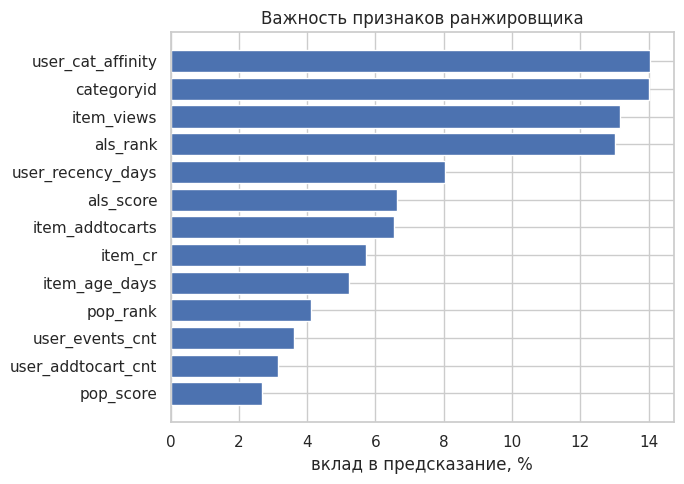

In [23]:
importance = pd.DataFrame(
    {"fi": ranker.get_feature_importance()}, index=RANKER_FEATURES
).sort_values("fi")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importance.index, importance["fi"], color="#4c72b0")
ax.set_title("Важность признаков ранжировщика")
ax.set_xlabel("вклад в предсказание, %")
plt.tight_layout()

fi_plot_path = f"{DATA_DIR}/ranker_feature_importance.png"
plt.savefig(fi_plot_path, dpi=100, bbox_inches="tight")
plt.show()

Оценка на тесте идёт по тем же правилам, что и на этапе 3: история —
окно `train`, база усреднения — те же пользователи, уже купленные товары из
выдачи убраны. Топ популярных и ALS считаются на том же пуле кандидатов, что
и ранжировщик, — тогда разница в метриках объясняется только порядком
товаров, а не разным набором. Сверяем их с числами этапа 3: они обязаны
совпасть, иначе где-то разъехались базы сравнения.

In [24]:
als_cand_test = als_recs(
    als_best_train, matrix_train, id_maps_train, base_test, bought_train,
    CANDIDATES["als_train"],
)
cand_test = build_candidates(
    als_cand_test, top_pop_train.head(CANDIDATES["popular_train"]),
    base_test, bought_train_raw,
)
X_test = ranker_features(cand_test, item_feats_train, user_feats_train, cat_aff_train)
X_test["cb_score"] = rank_candidates(ranker, X_test[RANKER_FEATURES])

# потолок пула: сколько позитивов теста вообще попало в кандидаты —
# выше этой планки вторая стадия подняться не может по построению
pos_test_base = pos_test[pos_test["visitorid"].isin(base_test)]
in_pool = cand_test.merge(pos_test_base, on=["visitorid", "itemid"])
ceiling_pairs = len(in_pool) / len(pos_test_base)
hits_in_pool = in_pool.groupby("visitorid").size().reindex(base_test).fillna(0)
n_rel_test = pos_test_base.groupby("visitorid").size().reindex(base_test)
ceiling_users = float((hits_in_pool / n_rel_test).mean())

print(f"кандидатов на тесте: {len(cand_test):,} "
      f"({len(cand_test) / len(base_test):.0f} на пользователя)")
print(f"потолок пула: {len(in_pool):,} из {len(pos_test_base):,} позитивных пар "
      f"({ceiling_pairs:.1%}); в пересчёте на пользователя {ceiling_users:.4f}")

кандидатов на тесте: 54,492 (142 на пользователя)
потолок пула: 71 из 1,053 позитивных пар (6.7%); в пересчёте на пользователя 0.0901


In [25]:
# у популярных товаров скор совпадает при равном числе добавлений в корзину,
# поэтому порядок задаём позицией в списке, а не скором
pool_pop = X_test[["visitorid", "itemid", "pop_rank"]].copy()
pool_pop["pop_order"] = -pool_pop["pop_rank"]

recs_pool_pop = top_by_score(pool_pop, TOP_K, "pop_order")
recs_pool_als = top_by_score(
    X_test[["visitorid", "itemid", "als_score"]], TOP_K, "als_score"
)
recs_ranker = top_by_score(
    X_test[["visitorid", "itemid", "cb_score"]], TOP_K, "cb_score"
)

pool_pop_metrics = evaluate(
    recs_pool_pop, pos_test, TOP_K, catalog_train, pop_train, base_test
)
pool_als_metrics = evaluate(
    recs_pool_als, pos_test, TOP_K, catalog_train, pop_train, base_test
)
ranker_test_metrics = evaluate(
    recs_ranker, pos_test, TOP_K, catalog_train, pop_train, base_test
)

check = pd.DataFrame(
    {
        "этап 3": [pop_test_metrics["recall"], best_test_metrics["recall"]],
        "тот же пул": [pool_pop_metrics["recall"], pool_als_metrics["recall"]],
    },
    index=["Топ популярных", "ALS + Optuna"],
).round(4)
print("сверка recall@10 с этапом 3:")
display(check)

сверка recall@10 с этапом 3:


,этап 3,тот же пул
Топ популярных,0.0070,0.0070
ALS + Optuna,0.0257,0.0257


In [26]:
test_results = pd.DataFrame(
    {
        "Топ популярных": pop_test_metrics,
        "ALS + Optuna": best_test_metrics,
        "ALS + ранжировщик": ranker_test_metrics,
    }
).T.round(4)
test_results = test_results.rename(columns=lambda c: f"{c}@{TOP_K}")
display(test_results)

,precision@10,recall@10,map@10,ndcg@10,coverage@10,novelty@10
Топ популярных,0.0021,0.0070,0.0050,0.0075,0.0001,10.8550
ALS + Optuna,0.0052,0.0257,0.0119,0.0180,0.0034,12.0094
ALS + ранжировщик,0.0084,0.0397,0.0249,0.0327,0.0046,11.9801


**Вывод по ранжировщику.** Вторая стадия улучшила все метрики точности:
recall@10 вырос с 0.0257 до 0.0397, precision@10 — с 0.0052 до 0.0084,
MAP@10 и NDCG@10 — примерно вдвое. Набор товаров у ALS и у ранжировщика
один и тот же, меняется только порядок, так что прирост целиком объясняется
второй стадией. Coverage при этом даже немного вырос, а novelty осталась
на прежнем уровне — модель не скатилась в популярное.

Читать эти числа стоит с двумя оговорками. Первая: обучающая выборка
ранжировщика маленькая. Пользователей, у которых есть и история в `train`,
и позитив в `labels`, набралось 525, а позитивных пар внутри пула — 176,
поэтому AUC на отложенных пользователях (0.91 против 0.97 на обучении)
заметно шумит, и разрыв между ними — обычное переобучение на редком классе.
Вторая: потолок схемы низкий. В пул кандидатов попадает 71 из 1053
позитивных пар теста, то есть 6.7 %, а в пересчёте на пользователя это
recall@10 не выше 0.090 — остальное упирается в кандидатогенератор, а не
в ранжирование.

In [27]:
with mlflow.start_run(run_name="Stage_4_Ranker_CatBoost") as run:
    mlflow.log_params({
        "model": "catboost_ranker",
        "candidates_als": CANDIDATES["als_train"],
        "candidates_popular": CANDIDATES["popular_train"],
        "negatives_per_user": N_NEGATIVES,
        "holdout_share": HOLDOUT_SHARE,
        "iterations": CB_PARAMS["iterations"],
        "learning_rate": CB_PARAMS["learning_rate"],
        "depth": CB_PARAMS["depth"],
        "cat_features": ",".join(CAT_FEATURES),
        "features": ",".join(RANKER_FEATURES),
        "seed": SEED,
        **SPLIT_DATES,
    })
    mlflow.log_metrics({
        "users_rank": len(base_rank),
        "train_rows": len(X_fit),
        "holdout_rows": len(X_hold),
        "train_positives": int(X_fit["target"].sum()),
        "holdout_positives": int(X_hold["target"].sum()),
        "candidate_ceiling_labels": ceiling_labels,
        "candidate_ceiling_test": ceiling_pairs,
        **{name: float(value) for name, value in ranker_quality.items()},
    })
    log_metrics(ranker_test_metrics, "test")
    mlflow.log_artifact(fi_plot_path)
    mlflow.log_artifact("../params.yaml")

    example = X_fit[RANKER_FEATURES].head(10)
    signature = infer_signature(example, rank_candidates(ranker, example))
    mlflow.catboost.log_model(
        ranker,
        name="ranker",
        signature=signature,
        input_example=example,
        registered_model_name=REGISTRY_MODEL_NAME,
        pip_requirements="../requirements.txt",
        await_registration_for=60,
    )
    run_id_ranker = run.info.run_id

print("run Stage_4_Ranker_CatBoost:", run_id_ranker)

Successfully registered model 'recsys_ranker_model'.


2026/09/11 20:32:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: recsys_ranker_model, version 1


Created version '1' of model 'recsys_ranker_model'.


run Stage_4_Ranker_CatBoost: 4de6c30b5de64294ab418bf8794620b5


## Этап 5. Финальная модель и артефакты для сервиса

Метрики выше посчитаны честно: модель обучена на `train` и проверена на
`test`, которого не видела. Перед выкаткой ALS дообучается на всей истории
(вместе с `labels` и `test`) с теми же гиперпараметрами, и признаки тоже
пересчитываются по всей истории — иначе сервис стартовал бы с моделью,
которая не знает последний месяц поведения покупателей. Ранжировщик при
этом не переобучается: он видел только пары из окна `labels` и остаётся тем
же файлом, который зарегистрирован в MLflow.

In [28]:
pairs_all = weight_events(events, EVENT_WEIGHTS)
matrix_all, id_maps_all = build_matrix(pairs_all)
als_all = fit_als(
    matrix_all, best["factors"], best["regularization"], best["iterations"], SEED
)
catalog_all = matrix_all.shape[1]

top_pop_all = top_popular(events, k=N_CANDIDATES)
sim_all = similar_items(als_all, np.arange(catalog_all), n=N_SIMILAR)
similar_all = pd.DataFrame({
    "itemid": decode(id_maps_all, "item", sim_all["item_enc"]),
    "similar_itemid": decode(id_maps_all, "item", sim_all["similar_enc"]),
    "score": sim_all["score"].to_numpy(),
    "rank": sim_all["rank"].to_numpy(),
})

print(f"матрица всей истории: {matrix_all.shape}, ненулевых {matrix_all.nnz:,}")
print(f"похожих товаров: {len(similar_all):,} строк "
      f"на {similar_all['itemid'].nunique():,} товаров")
display(top_pop_all.head())

матрица всей истории: (1407580, 235061), ненулевых 2,145,179
похожих товаров: 2,350,610 строк на 235,061 товаров


,itemid,score,rank
0,461686,0.000190,1
1,320130,0.000093,2
2,312728,0.000092,3
3,409804,0.000091,4
4,29196,0.000072,5


Персональные рекомендации считаем для пользователей, у которых в истории
есть хотя бы два события: по одному просмотру ALS почти не отличает
визитёра от среднего, а список на каждого из полутора миллионов визитёров
раздул бы файл втрое. Пул кандидатов на выкатке короче, чем при обучении, —
50 позиций от ALS и 20 из топа популярных: сервис всё равно отдаёт не
больше 20 рекомендаций, и держать под них полторы сотни кандидатов незачем.
Считаем чанками по 50 тысяч пользователей, иначе таблица кандидатов не
помещается в память.

In [29]:
item_feats_all = item_features(events, items)
user_feats_all = user_features(events)
cat_aff_all = user_category_affinity(events, items)

bought_all_raw = user_history_purchases(events)
bought_all = bought_enc(events, id_maps_all)

user_counts = events.groupby("visitorid").size()
serve_users = np.sort(user_counts[user_counts >= MIN_USER_EVENTS].index.to_numpy())
pop_serve = top_pop_all.head(CANDIDATES["popular_serving"])

chunks = []
for start in range(0, len(serve_users), 50_000):
    part_users = serve_users[start:start + 50_000]
    als_part = als_recs(
        als_all, matrix_all, id_maps_all, part_users, bought_all,
        CANDIDATES["als_serving"],
    )
    cand_part = build_candidates(als_part, pop_serve, part_users, bought_all_raw)
    feats_part = ranker_features(
        cand_part, item_feats_all, user_feats_all, cat_aff_all
    )
    feats_part["score"] = rank_candidates(ranker, feats_part[RANKER_FEATURES])
    chunks.append(top_by_score(feats_part[["visitorid", "itemid", "score"]], RECS_TOP_N))

recommendations = pd.concat(chunks, ignore_index=True).rename(
    columns={"visitorid": "user_id", "itemid": "item_id"}
)
recommendations = recommendations.astype(
    {"user_id": "int64", "item_id": "int64", "score": "float32", "rank": "int16"}
)

print(f"пользователей с персональными рекомендациями: {len(serve_users):,} "
      f"из {events['visitorid'].nunique():,}")
print(f"строк в recommendations: {len(recommendations):,}")
print(f"уникальных товаров в выдаче: {recommendations['item_id'].nunique():,}")
display(recommendations.head())

пользователей с персональными рекомендациями: 406,020 из 1,407,580
строк в recommendations: 8,120,400
уникальных товаров в выдаче: 10,733


,user_id,item_id,score,rank
0,0,357564,0.170874,1
1,0,227211,0.086044,2
2,0,461686,0.033384,3
3,0,320130,0.028964,4
4,0,312728,0.022104,5


Модель ALS на всей истории остаётся лежать локально в `models/` — в бакет
она не заливается. Канал наружу около 0,1 МБ/с, а файл получается почти на
гигабайт: такая заливка заняла бы больше двух часов и ничего бы не дала,
модель нужна только для расчёта рекомендаций. В MLflow вместо файла кладётся
манифест с ключами и размерами. В S3 отправляются три parquet-таблицы,
которые читает сервис, — они заменяют версии, посчитанные на `train`. Размер
и время каждой заливки печатаются: по ним видно, насколько узкий канал.

In [30]:
os.makedirs(CV_DIR, exist_ok=True)
als_all_path = f"{MODELS_DIR}/als_model.npz"
save_als(als_all, als_all_path)
id_maps_all.to_parquet(f"{DATA_DIR}/id_maps_all.parquet", index=False)

recs_path = f"{DATA_DIR}/recommendations.parquet"
top_popular_all_path = f"{DATA_DIR}/top_popular_all.parquet"
similar_all_path = f"{DATA_DIR}/similar_items_all.parquet"

# zstd вместо snappy: тот же файл получается почти на пятую часть меньше,
# а при 0,1 МБ/с каждые десять мегабайт — это лишние полторы минуты заливки
recommendations.to_parquet(recs_path, index=False, compression="zstd")
top_pop_all.to_parquet(top_popular_all_path, index=False)
similar_all.to_parquet(similar_all_path, index=False)

upload_log = []
for local_path, key in [
    (recs_path, RECS_PERSONAL_PATH),
    (top_popular_all_path, RECS_DEFAULT_PATH),
    (similar_all_path, SIMILAR_PATH),
]:
    size_mb = os.path.getsize(local_path) / 1e6
    started = time.time()
    upload_file(local_path, key)
    spent = time.time() - started
    upload_log.append({
        "ключ": key,
        "размер, МБ": round(size_mb, 1),
        "время, с": round(spent, 1),
        "скорость, МБ/с": round(size_mb / spent, 3),
    })

print(f"модель ALS на всей истории: {os.path.getsize(als_all_path) / 1e6:.0f} МБ, "
      f"лежит локально в {MODELS_DIR}")
display(pd.DataFrame(upload_log))

модель ALS на всей истории: 841 МБ, лежит локально в ../models


,ключ,"размер, МБ","время, с","скорость, МБ/с"
0,recsys_final/recommendations/recommendations.p...,32.4,680.5,0.048
1,recsys_final/recommendations/top_popular.parquet,0.0,0.9,0.004
2,recsys_final/recommendations/similar_items.par...,23.5,233.9,0.100


In [31]:
model_params = {
    "splits": SPLIT_DATES,
    "event_weights": EVENT_WEIGHTS,
    "als_best": {
        "factors": best["factors"],
        "regularization": best["regularization"],
        "iterations": best["iterations"],
    },
    "catboost": {
        **CB_PARAMS,
        "trees_used": int(ranker.tree_count_),
        "cat_features": CAT_FEATURES,
        "features": RANKER_FEATURES,
        "negatives_per_user": N_NEGATIVES,
        "holdout_share": HOLDOUT_SHARE,
    },
    "candidates": CANDIDATES,
    "top_k": TOP_K,
    "n_similar": N_SIMILAR,
    "min_user_events": MIN_USER_EVENTS,
    "recs_top_n": RECS_TOP_N,
    "seed": SEED,
}
with open(f"{MODELS_DIR}/model_params.json", "w") as fd:
    json.dump(model_params, fd, indent=2, ensure_ascii=False)

metrics_json = {
    "top_k": TOP_K,
    "users_valid": int(len(base_valid)),
    "users_test": int(len(base_test)),
    "candidate_ceiling_test": float(ceiling_pairs),
    "ranker": {name: float(value) for name, value in ranker_quality.items()},
    "valid": {
        "top_popular": pop_valid_metrics,
        "als": als_valid_metrics,
        "als_optuna": best_valid_metrics,
    },
    "test": {
        "top_popular": pop_test_metrics,
        "als": als_test_metrics,
        "als_optuna": best_test_metrics,
        "als_ranker": ranker_test_metrics,
    },
}
with open(f"{CV_DIR}/metrics.json", "w") as fd:
    json.dump(metrics_json, fd, indent=2, ensure_ascii=False)

print(json.dumps(metrics_json["test"], indent=2, ensure_ascii=False))

{
  "top_popular": {
    "precision": 0.0020887728459530026,
    "recall": 0.006972567186052058,
    "map": 0.005007459903021261,
    "ndcg": 0.00747020450361473,
    "coverage": 7.490215905473475e-05,
    "novelty": 10.85500507327172
  },
  "als": {
    "precision": 0.006005221932114883,
    "recall": 0.023536250566178453,
    "map": 0.006976373520107201,
    "ndcg": 0.014106659908940387,
    "coverage": 0.0025045409433926934,
    "novelty": 11.695542811194375
  },
  "als_optuna": {
    "precision": 0.005221932114882507,
    "recall": 0.025658892891268874,
    "map": 0.011883003854283225,
    "ndcg": 0.01795898431221164,
    "coverage": 0.003440817931576878,
    "novelty": 12.009425690448362
  },
  "als_ranker": {
    "precision": 0.00835509138381201,
    "recall": 0.03970185559419164,
    "map": 0.024904160968129637,
    "ndcg": 0.03266385900482793,
    "coverage": 0.004601801396925266,
    "novelty": 11.980121111745854
  }
}


In [32]:
with mlflow.start_run(run_name="Stage_4_FINAL_MODEL") as run:
    mlflow.log_params({
        "model": "als_candidates_plus_catboost",
        "fit_window": "вся история 2015-05-03 — 2015-09-18",
        "als_factors": best["factors"],
        "als_regularization": best["regularization"],
        "als_iterations": best["iterations"],
        "candidates_serving": (
            f"als {CANDIDATES['als_serving']} + "
            f"popular {CANDIDATES['popular_serving']}"
        ),
        "min_user_events": MIN_USER_EVENTS,
        "recs_top_n": RECS_TOP_N,
        "seed": SEED,
    })
    mlflow.log_metrics({
        "serve_users": len(serve_users),
        "recs_rows": len(recommendations),
        "recs_items": recommendations["item_id"].nunique(),
        "recs_file_mb": os.path.getsize(recs_path) / 1e6,
        "similar_rows": len(similar_all),
    })
    for name, metrics in metrics_json["test"].items():
        log_metrics(metrics, f"test_{name}")

    manifest = {
        "recommendations": f"s3://{S3_BUCKET}/{RECS_PERSONAL_PATH}",
        "top_popular": f"s3://{S3_BUCKET}/{RECS_DEFAULT_PATH}",
        "similar_items": f"s3://{S3_BUCKET}/{SIMILAR_PATH}",
        "als_model_s3": f"s3://{S3_BUCKET}/{ALS_MODEL_PATH} (обучен на train, этап 3)",
        "als_model_local": f"{als_all_path} (обучен на всей истории, в бакет не залит)",
        "uploads": upload_log,
    }
    manifest_path = f"{DATA_DIR}/artifacts_final.json"
    with open(manifest_path, "w") as fd:
        json.dump(manifest, fd, indent=2, ensure_ascii=False)

    sample_path = f"{DATA_DIR}/recommendations_sample.parquet"
    recommendations.head(1000).to_parquet(sample_path, index=False)

    mlflow.log_artifact(f"{MODELS_DIR}/model_params.json")
    mlflow.log_artifact(f"{CV_DIR}/metrics.json")
    mlflow.log_artifact(manifest_path)
    mlflow.log_artifact(sample_path)
    mlflow.log_artifact("../params.yaml")
    run_id_final_model = run.info.run_id

print("run Stage_4_FINAL_MODEL:", run_id_final_model)

run Stage_4_FINAL_MODEL: 6540efcd1b3944c6923f01a26b2bc88a


В Model Registry уходит только ранжировщик: у `implicit` нет flavor в
MLflow, поэтому ALS зарегистрировать нечем — для него в запуске лежат
параметры, метрики и манифест с ключами файла в S3. Проверяем, что версия
ранжировщика действительно создалась.

In [33]:
client = mlflow.MlflowClient()
registry = pd.DataFrame([
    {
        "модель": version.name,
        "версия": version.version,
        "run_id": version.run_id,
        "статус": version.status,
    }
    for version in client.search_model_versions(f"name='{REGISTRY_MODEL_NAME}'")
])
display(registry)

keys = list_objects(f"{S3_PREFIX}/recommendations")
print("артефакты сервиса в бакете:")
for key in keys:
    print(f"  {key}")

,модель,версия,run_id,статус
0,recsys_ranker_model,1,4de6c30b5de64294ab418bf8794620b5,READY


артефакты сервиса в бакете:
  recsys_final/recommendations/recommendations.parquet
  recsys_final/recommendations/similar_items.parquet
  recsys_final/recommendations/top_popular.parquet


## Итоговые выводы

1. **Разбиение.** История Retailrocket поделена по времени на четыре окна:
   `train_fit` (обучение при подборе), `valid` (подбор гиперпараметров),
   `labels` (таргет ранжировщика) и `test` (единственное окно итоговых
   метрик). Случайного сплита нет нигде, тестовое окно не участвует ни в
   обучении, ни в подборе.
2. **Базовая модель.** Топ популярных по числу добавлений в корзину даёт
   precision@10 0.0021 и recall@10 0.0070 при почти нулевом coverage — все
   получают один и тот же десяток товаров.
3. **ALS.** Персональная модель на 128 факторах, подобранных Optuna по
   recall@10 на валидации, поднимает recall@10 до 0.0257 и precision@10 до
   0.0052 — в три-четыре раза выше базовой, и покрывает уже не десяток
   товаров, а тысячи.
4. **Двухстадийная схема.** Ранжирование пула кандидатов CatBoost-ом
   добавило ещё примерно половину: recall@10 0.0397, precision@10 0.0084,
   MAP@10 0.0249. Набор товаров у ALS и у ранжировщика один и тот же,
   поэтому прирост объясняется только порядком выдачи. Самые полезные
   признаки — доля событий пользователя в категории товара, сама категория,
   просмотры товара и позиция кандидата в списке ALS.
5. **Потолок.** Ограничение схемы — не ранжирование, а генерация
   кандидатов: в пул попадает 71 из 1053 позитивных пар теста (6.7 %), и
   даже идеальная вторая стадия не подняла бы recall@10 выше 0.090 при
   достигнутых 0.0397.
   Следующий шаг по качеству — добавить кандидатогенераторы (i2i по
   последнему просмотру, контентный по категории), а не усложнять
   ранжировщик.
6. **Абсолютные значения.** Метрики низкие, и это нормально: добавления в
   корзину делают около 3 % визитёров, каталог — 235 тысяч товаров, окно
   оценки — 15 дней, а база усреднения составляет 383 пользователя с
   историей и позитивом в тесте. База одна и та же у всех моделей, поэтому
   сравнение между ними корректно, но сами числа шумные.
7. **Артефакты для сервиса.** Перед выкаткой ALS и признаки пересчитаны на
   всей истории, ранжировщик оставлен тем же. В S3 лежат
   `recommendations/recommendations.parquet` (top-20 на пользователя),
   `recommendations/top_popular.parquet` и `recommendations/similar_items.parquet`;
   файл ранжировщика `models/catboost_ranker.cbm` и параметры
   `models/model_params.json` закоммичены, метрики — в
   `cv_results/metrics.json`.
8. **Воспроизводимость.** `SEED = 42` проброшен в ALS, CatBoost, Optuna и
   в семплирование негативов; гиперпараметры и границы окон читаются из
   `params.yaml`, а не задаются в ноутбуке руками.